# Switchboard (MSU / ISIP) transcripts: size, annotation schema, disfluencies, duration

[Corpus Download Link](https://openslr.trmal.net/resources/5/switchboard_word_alignments.tar.gz)

1. **Corpus size**: transcripts, conversations, utterances, words.
2. **Annotation schema**: every kind of markup that occurs in the transcripts, what it means, how often it occurs.
3. **Disfluency statistics**: for each type, how many, how often per 1,000 words, in how many transcripts, and how long (from the word alignments).
4. **Duration**: for every transcript and for the whole corpus.

**Data.** `data/MSU Switchboard/swb_ms98_transcriptions/`. Each conversation (`sw2001`) has two transcripts, one per speaker (side `A` and `B`), each with
`*-ms98-a-trans.text` (utterances: `id  start  end  text`) and `*-ms98-a-word.text` (one line per word or silence, with times).
`switchboard_word_alignments.tar.gz` in the same folder is an archive of these same files, so it is not read.

**Needs** `pandas` and `matplotlib` (`pip install pandas matplotlib`; run with pandas 3.0.6 and matplotlib 3.11.2); takes about a minute and ~2 GB of memory.

In [1]:
import collections, re, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.2f}".format)


def find_corpus():
    """data/MSU Switchboard/swb_ms98_transcriptions, looked for next to this notebook and one folder up."""
    for base in (Path.cwd(), Path.cwd().parent):
        for folder in (base / "data").glob("*"):
            if folder.name.strip() == "MSU Switchboard" and (folder / "swb_ms98_transcriptions").is_dir():
                return folder / "swb_ms98_transcriptions"
    raise FileNotFoundError("data/MSU Switchboard/swb_ms98_transcriptions not found")


CORPUS = find_corpus()
print(CORPUS)

/Users/imradhe/Projects/Disfluency Restoration/data/MSU Switchboard/swb_ms98_transcriptions


## 1. The annotation schema

The corpus README only describes the release, so the schema comes from two places: the header of `sw-ms98-dict.text`, which lists the categories
*partial words, words containing laughter, common alternate pronunciations, hesitation sounds, proper nouns, anomalous words, coinages*,
and the transcripts themselves. Markers the dictionary does not document (`[silence]`, `[noise]`, `[laughter]`, `[vocalized-noise]`,
`<b_aside>`) are marked *inferred from the data* below.

The groupings used for the statistics are this notebook's choices, not the corpus's, and are easy to change here:
the dictionary lists `uh-huh` and `um-hum` among its "hesitations", but they are listening acknowledgements, so they get their own group.

In [2]:
FILLED_PAUSES = {"uh", "um", "hm", "ah", "eh"}
BACKCHANNELS = {"uh-huh", "um-hum", "huh-uh", "hum-um", "uh-hum"}
OTHER_HESITATIONS = {"huh", "ooh", "uh-oh"}  # in the dictionary's hesitation list, but really exclamations
VARIANT = re.compile(r"_\d+$")


def classify(token):
    """Annotation category of one transcript token. The first matching rule wins."""
    if token == "[silence]":
        return "silence"
    if token == "[noise]":
        return "noise"
    if token == "[vocalized-noise]":
        return "vocalized_noise"
    if token == "[laughter]":
        return "laughter"
    if token.startswith("[laughter-"):
        return "laughter_word"  # [laughter-yeah]: a word spoken while laughing
    if token in ("<b_aside>", "<e_aside>"):
        return "aside_marker"
    if token.startswith("{") and token.endswith("}"):
        return "coinage"  # {alrighty}
    if token.startswith("[") and token.endswith("]") and "/" in token:
        return "mispronounced"  # [tranged/changed]: [as spoken / intended word]
    if ("[" in token or "]" in token) and (token.endswith("-") or token.startswith("-")):
        return "partial_word"  # y[ou]-  or  -[o]kay
    if token.endswith("-") or token.startswith("-"):
        return "cutoff_word"  # i-
    lower = token.lower()
    if lower in FILLED_PAUSES:
        return "filled_pause"
    if lower in BACKCHANNELS:
        return "backchannel"
    if lower in OTHER_HESITATIONS:
        return "other_hesitation"
    if VARIANT.search(token):
        return "pron_variant"  # them_1, because_1: reduced pronunciation of the word
    return "word"


# One row per annotation category: (category, group, how it looks, what it means, where it is documented)
SCHEMA = [
    ("filled_pause", "disfluency", "uh  um  hm  ah  eh", "Filled pause / hesitation sound", "dictionary: hesitations"),
    ("other_hesitation", "disfluency", "huh  ooh  uh-oh", "Hesitation-list items that are really exclamations", "dictionary: hesitations"),
    ("partial_word", "disfluency", "y[ou]-   -[o]kay", "Word fragment. Spoken part outside the brackets, unspoken part inside; "
     "the dash marks where the word was cut off (end) or where it began (start)", "dictionary: partial words"),
    ("cutoff_word", "disfluency", "i-", "A whole word cut off, marked with a trailing dash", "inferred (dash convention)"),
    ("mispronounced", "disfluency", "[tranged/changed]", "[as spoken / intended word]: a mispronunciation or slip", "dictionary: anomalous words"),
    ("repeat_1", "disfluency", "(no tag)", "One word repeated: 'and and'. Detected by this notebook", "derived"),
    ("repeat_2", "disfluency", "(no tag)", "Two words repeated: 'is there is there'. Detected by this notebook", "derived"),
    ("repeat_3", "disfluency", "(no tag)", "Three words repeated. Detected by this notebook", "derived"),
    ("backchannel", "conversational", "uh-huh  um-hum  huh-uh", "Acknowledgement while the other person talks", "dictionary: hesitations"),
    ("silence", "non-speech", "[silence]", "No speech from this speaker", "inferred from the data"),
    ("noise", "non-speech", "[noise]", "Non-speech noise", "inferred from the data"),
    ("vocalized_noise", "non-speech", "[vocalized-noise]", "Non-speech sound made with the voice", "inferred from the data"),
    ("laughter", "non-speech", "[laughter]", "Laughter", "inferred from the data"),
    ("laughter_word", "word markup", "[laughter-yeah]", "A word spoken while laughing", "dictionary: words containing laughter"),
    ("pron_variant", "word markup", "them_1  because_1", "Alternate pronunciation of the word (reduced forms)", "dictionary: alternate pronunciations"),
    ("coinage", "word markup", "{alrighty}", "A newly coined or non-standard word", "dictionary: coinages"),
    ("aside_marker", "word markup", "<b_aside>  <e_aside>", "Begin / end of an aside; zero duration in the alignments", "inferred from the data"),
    ("word", "word", "everything else", "An ordinary word", "-"),
]
schema = pd.DataFrame(SCHEMA, columns=["category", "group", "looks_like", "meaning", "documented"]).set_index("category")
ALL_CATEGORIES = list(schema.index)

# Tokens that count as words, for 'per 1,000 words' rates (not fragments, pauses, noises or markers)
LEXICAL = ["word", "pron_variant", "coinage", "mispronounced", "laughter_word"]
# Disfluency rows with no token-level alignment of their own
DERIVED = ["repeat_1", "repeat_2", "repeat_3"]

## 2. Load the transcripts and the word alignments

In [3]:
# Utterance transcripts: one line per utterance, "sw2001A-ms98-a-0002  0.977625  11.561375  hi um yeah ..."
rows = []
for path in sorted(CORPUS.glob("*/*/*-trans.text")):
    conversation, side = path.name[:6], path.name[6]  # sw2001, A
    for line in path.read_text(errors="replace").splitlines():
        utt_id, start, end, text = line.split(None, 3)  # split on any whitespace, at most 3 times
        rows.append((conversation, side, utt_id, float(start), float(end), text))

utts = pd.DataFrame(rows, columns=["conversation", "side", "utt_id", "start", "end", "text"])
utts["transcript"] = utts["conversation"] + utts["side"]  # sw2001A: one speaker of one conversation
del rows
print(f"{utts['transcript'].nunique():,} transcripts, {len(utts):,} utterances")

4,876 transcripts, 391,593 utterances


In [4]:
# Word alignments: one line per word or silence, "sw2001A-ms98-a-0002  1.215250  1.724625  hi".
# 158 of the 4,876 files (2.7% of all lines) separate the fields with tabs or runs of spaces, hence split() with no argument.
conversation, side, start, end, token = [], [], [], [], []
for path in sorted(CORPUS.glob("*/*/*-word.text")):
    c, s = path.name[:6], path.name[6]
    for line in path.read_text(errors="replace").splitlines():
        _, a, b, t = line.split()
        conversation.append(c)
        side.append(s)
        start.append(float(a))
        end.append(float(b))
        token.append(sys.intern(t))

words = pd.DataFrame({"conversation": conversation, "side": side, "start": start, "end": end, "token": token})
del conversation, side, start, end, token
words["transcript"] = (words["conversation"] + words["side"]).astype("category")
words["duration"] = words["end"] - words["start"]
words["category"] = words["token"].map({t: classify(t) for t in words["token"].unique()}).astype("category")
words["token"] = words["token"].astype("category")
print(f"{len(words):,} aligned tokens")

# Sanity checks: every transcript has both files, and they cover the same time span
last_utt = utts.groupby("transcript")["end"].max()
last_word = words.groupby("transcript", observed=True)["end"].max()
print("transcript and word files cover the same transcripts:", set(last_utt.index) == set(last_word.index))
print("and end at the same time:", bool(((last_utt - last_word).abs() < 1e-6).all()))

4,051,206 aligned tokens
transcript and word files cover the same transcripts: True
and end at the same time: True


In [5]:
# Classify every token once. Per utterance: how many tokens of each category, plus detected repetitions.
def repetitions(lexical):
    """Immediate repeats of 1-3 words: 'is there is there' is one 2-word repeat. Returns [(n, text), ...].
    A run of one word ('the the the') is counted as 1-word repeats, one per extra copy, never as a longer repeat."""
    found, i = [], 0
    while i < len(lexical):
        for n in (3, 2, 1):
            if n > 1 and len(set(lexical[i:i + n])) == 1:
                continue
            if i + 2 * n <= len(lexical) and lexical[i:i + n] == lexical[i + n:i + 2 * n]:
                found.append((n, " ".join(lexical[i:i + 2 * n])))
                i += n
                break
        else:
            i += 1
    return found


per_utt = []
forms = collections.defaultdict(collections.Counter)  # category -> {exact token: count}
for text in utts["text"]:
    counts, lexical = collections.Counter(), []
    for token in text.split():
        category = classify(token)
        counts[category] += 1
        forms[category][token] += 1
        if category in ("word", "pron_variant"):  # repetitions are looked for among ordinary words, so
            lexical.append(token.lower())          # 'the uh the' still counts: fillers and noises are skipped
    for n, example in repetitions(lexical):
        counts[f"repeat_{n}"] += 1
        forms[f"repeat_{n}"][example] += 1
    per_utt.append(counts)

counts = pd.DataFrame(per_utt, columns=ALL_CATEGORIES).fillna(0).astype(int)  # rows line up with utts
per_transcript = counts.groupby(utts["transcript"]).sum()  # category counts per transcript
del per_utt
print(f"{int(counts.drop(columns=DERIVED).to_numpy().sum()):,} tokens classified")

3,259,311 tokens classified


## 3. Corpus size and duration

A transcript's duration is the end time of its last utterance, i.e. the length of that speaker's side of the call.
`silence_s` is the time the speaker says nothing (`[silence]` in the word alignments); `speaking_s` is the rest, including noises and laughter.

In [6]:
duration = utts.groupby("transcript")["end"].max()  # seconds
silence = words[words["category"] == "silence"].groupby("transcript", observed=True)["duration"].sum()
n_words = per_transcript[LEXICAL].sum(axis=1)

overview = pd.Series({
    "transcripts (one per speaker per conversation)": f"{len(duration):,}",
    "conversations": f"{utts['conversation'].nunique():,}",
    "utterances": f"{len(utts):,}",
    "tokens, including markup": f"{int(counts.drop(columns=DERIVED).to_numpy().sum()):,}",
    "words (excluding fragments, pauses, noises)": f"{int(n_words.sum()):,}",
    "distinct token forms": f"{len(words['token'].cat.categories):,}",
    "total duration": f"{duration.sum() / 3600:,.1f} hours  ({duration.sum():,.0f} s)",
    "total silence": f"{silence.sum() / 3600:,.1f} hours  ({100 * silence.sum() / duration.sum():.1f}% of the time)",
    "total speaking": f"{(duration.sum() - silence.sum()) / 3600:,.1f} hours",
}).to_frame("value")
display(overview)

per_conv = duration.groupby(utts.drop_duplicates("transcript").set_index("transcript")["conversation"]).max()
display(pd.DataFrame({
    "per transcript (minutes)": (duration / 60).describe(),
    "per conversation (minutes)": (per_conv / 60).describe(),
}).loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

,value
transcripts (one per speaker per conversation),"4,876"
conversations,"2,438"
utterances,"391,593"
"tokens, including markup","3,259,311"
"words (excluding fragments, pauses, noises)","2,930,082"
distinct token forms,"38,649"
total duration,"518.3 hours (1,865,856 s)"
total silence,290.8 hours (56.1% of the time)
total speaking,227.5 hours


,per transcript (minutes),per conversation (minutes)
count,"4,876.00","2,438.00"
mean,6.38,6.38
std,2.09,2.09
min,0.85,0.85
25%,4.98,4.98
50%,4.99,4.99
75%,7.84,7.84
max,10.03,10.03


## 4. Annotation schema with counts

Every kind of markup, with how often it occurs. `looks_like` shows the notation; `top forms` are the most common exact tokens in the data.
Rows marked *derived* have no tag in the transcripts: repetitions are detected by `repetitions()` above.

In [7]:
total_tokens = int(counts.drop(columns=DERIVED).to_numpy().sum())
overview_schema = schema.copy()
overview_schema["tokens"] = counts.sum()
overview_schema["% of tokens"] = [100 * t / total_tokens if c not in DERIVED else None for c, t in overview_schema["tokens"].items()]
overview_schema["distinct forms"] = [len(forms[c]) for c in overview_schema.index]
overview_schema["top forms"] = [", ".join(f"{w} ({n:,})" for w, n in forms[c].most_common(4)) for c in overview_schema.index]
display(overview_schema[["group", "looks_like", "meaning", "documented", "tokens", "% of tokens", "distinct forms", "top forms"]])

,group,looks_like,meaning,documented,tokens,% of tokens,distinct forms,top forms
category,,,,,,,,
filled_pause,disfluency,uh um hm ah eh,Filled pause / hesitation sound,dictionary: hesitations,92389,2.83,6,"uh (69,814), um (21,187), hm (1,010), ah (353)"
other_hesitation,disfluency,huh ooh uh-oh,Hesitation-list items that are really exclamations,dictionary: hesitations,2107,0.06,3,"huh (1,862), ooh (226), uh-oh (19)"
partial_word,disfluency,y[ou]- -[o]kay,"Word fragment. Spoken part outside the brackets, unspoken part inside; the d...",dictionary: partial words,23797,0.73,6257,"i[t]- (784), y[ou]- (734), an[d]- (495), th[e]- (393)"
cutoff_word,disfluency,i-,"A whole word cut off, marked with a trailing dash",inferred (dash convention),4733,0.15,1,"i- (4,733)"
mispronounced,disfluency,[tranged/changed],[as spoken / intended word]: a mispronunciation or slip,dictionary: anomalous words,341,0.01,334,"[tranged/changed] (2), [what'n/wasn't] (2), [hem/hormones] (2), [bidness/bus..."
repeat_1,disfluency,(no tag),One word repeated: 'and and'. Detected by this notebook,derived,55775,NaN,1128,"and and (5,456), i i (5,277), the the (4,381), yeah yeah (2,704)"
repeat_2,disfluency,(no tag),Two words repeated: 'is there is there'. Detected by this notebook,derived,9876,NaN,2257,"i don't i don't (389), it was it was (316), i think i think (268), in the in..."
repeat_3,disfluency,(no tag),Three words repeated. Detected by this notebook,derived,1801,NaN,1159,"i don't know i don't know (53), a lot of a lot of (39), what do you what do ..."
backchannel,conversational,uh-huh um-hum huh-uh,Acknowledgement while the other person talks,dictionary: hesitations,32724,1.00,5,"uh-huh (16,294), um-hum (16,006), huh-uh (269), hum-um (96)"


## 5. Disfluency statistics

For each type: total count, rate per 1,000 words, how many utterances and transcripts contain it, and the per-transcript spread of the rate.
Backchannels are included as a conversational reference point; non-speech markers are in the table above.

In [8]:
DISFLUENCIES = ["filled_pause", "other_hesitation", "partial_word", "cutoff_word", "mispronounced"] + DERIVED + ["backchannel"]
rate = per_transcript[DISFLUENCIES].div(n_words, axis=0) * 1000  # per 1,000 words, per transcript

stats = pd.DataFrame({
    "group": schema.loc[DISFLUENCIES, "group"],
    "tokens": counts[DISFLUENCIES].sum(),
    "per 1,000 words": 1000 * counts[DISFLUENCIES].sum() / n_words.sum(),
    "utterances with": (counts[DISFLUENCIES] > 0).sum(),
    "% of utterances": 100 * (counts[DISFLUENCIES] > 0).mean(),
    "transcripts with": (per_transcript[DISFLUENCIES] > 0).sum(),
    "rate / transcript: mean": rate.mean(),
    "median": rate.median(),
    "max": rate.max(),
})
display(stats)

,group,tokens,"per 1,000 words",utterances with,% of utterances,transcripts with,rate / transcript: mean,median,max
filled_pause,disfluency,92389,31.53,65695,16.78,4851,33.07,29.07,209.23
other_hesitation,disfluency,2107,0.72,2083,0.53,1278,0.89,0.00,64.10
partial_word,disfluency,23797,8.12,20461,5.23,4529,8.43,6.83,73.30
cutoff_word,disfluency,4733,1.62,3995,1.02,2002,1.70,0.00,51.28
mispronounced,disfluency,341,0.12,329,0.08,303,0.13,0.00,17.09
repeat_1,disfluency,55775,19.04,42008,10.73,4789,18.82,16.59,107.82
repeat_2,disfluency,9876,3.37,9238,2.36,3510,3.28,2.44,26.32
repeat_3,disfluency,1801,0.61,1771,0.45,1319,0.59,0.00,12.10
backchannel,conversational,32724,11.17,31226,7.97,4143,13.62,7.94,280.00


In [9]:
# Per type, the exact forms behind the counts
for category in DISFLUENCIES:
    top = ", ".join(f"{w} ({n:,})" for w, n in forms[category].most_common(10))
    print(f"{category:17} {top}")

filled_pause      uh (69,814), um (21,187), hm (1,010), ah (353), eh (16), Um (9)
other_hesitation  huh (1,862), ooh (226), uh-oh (19)
partial_word      i[t]- (784), y[ou]- (734), an[d]- (495), th[e]- (393), a[nd]- (334), tha[t]- (299), w[ell]- (259), th[at]- (259), ha[ve]- (227), we[ll]- (225)
cutoff_word       i- (4,733)
mispronounced     [tranged/changed] (2), [what'n/wasn't] (2), [hem/hormones] (2), [bidness/business] (2), [Discover/Discovery] (2), [burgalies/burglaries] (2), [decifit/deficit] (2), [disea[l]-/diesel] (1), [cha[pe]-/shape] (1), [ananimous/unanimous] (1)
repeat_1          and and (5,456), i i (5,277), the the (4,381), yeah yeah (2,704), a a (2,500), that that (2,485), it's it's (2,308), it it (1,871), they they (1,552), to to (1,389)
repeat_2          i don't i don't (389), it was it was (316), i think i think (268), in the in the (238), that's right that's right (159), do you do you (147), you know you know (138), i was i was (110), it's a it's a (109), that's true 

## 6. How long each disfluency lasts

Durations come from the word alignments (ISIP's forced alignment, manually reviewed for speech vs non-speech). Repetitions have no
token of their own, so they are not listed. `% of recording` is the share of all recorded time spent on that category.

In [10]:
timed = ["filled_pause", "other_hesitation", "partial_word", "cutoff_word", "mispronounced", "backchannel",
         "laughter", "laughter_word", "noise", "vocalized_noise", "silence"]
by_category = words[words["category"].isin(timed)].groupby("category", observed=True)["duration"]

durations = pd.DataFrame({
    "tokens": by_category.count(),
    "mean (ms)": by_category.mean() * 1000,
    "median (ms)": by_category.median() * 1000,
    "5th pct (ms)": by_category.quantile(0.05) * 1000,
    "95th pct (ms)": by_category.quantile(0.95) * 1000,
    "total (hours)": by_category.sum() / 3600,
})
durations["% of recording"] = 100 * by_category.sum() / duration.sum()
display(durations.loc[[c for c in timed if c in durations.index]])

# The individual hesitation forms
forms_timed = words[words["token"].isin(["uh", "um", "hm", "ah", "eh", "uh-huh", "um-hum"])]
display(forms_timed.groupby("token", observed=True)["duration"].agg(["count", "mean", "median"]).mul({"count": 1, "mean": 1000, "median": 1000})
        .rename(columns={"mean": "mean (ms)", "median": "median (ms)"}).sort_values("count", ascending=False))

,tokens,mean (ms),median (ms),5th pct (ms),95th pct (ms),total (hours),% of recording
category,,,,,,,
filled_pause,92389,335.73,316.00,120.00,615.32,8.62,1.66
other_hesitation,2107,357.49,326.63,150.00,701.84,0.21,0.04
partial_word,23797,213.09,190.00,60.00,430.00,1.41,0.27
cutoff_word,4733,199.41,188.25,60.23,365.17,0.26,0.05
mispronounced,341,465.35,437.13,212.63,837.37,0.04,0.01
backchannel,32724,422.06,405.62,260.75,637.75,3.84,0.74
laughter,22209,985.49,810.00,242.43,"2,298.20",6.08,1.17
laughter_word,13504,488.78,385.12,109.25,"1,233.28",1.83,0.35
noise,17962,501.62,372.88,12.25,"1,301.96",2.50,0.48


,count,mean (ms),median (ms)
token,,,
uh,69814,306.29,285.62
um,21187,431.32,417.62
uh-huh,16294,419.50,402.37
um-hum,16006,424.26,408.56
hm,1010,345.24,326.94
ah,353,389.89,346.75
eh,16,283.38,215.56


## 7. Per transcript

One row per transcript: duration and the rate of every disfluency type per 1,000 words.

In [11]:
per_t = pd.DataFrame({
    "duration_s": duration,
    "silence_s": silence,
    "utterances": utts.groupby("transcript").size(),
    "words": n_words,
})
per_t["speaking_s"] = per_t["duration_s"] - per_t["silence_s"]
for category in DISFLUENCIES:
    per_t[f"{category} /1000w"] = rate[category]
per_t = per_t.reset_index()
display(per_t.head(10))
display(per_t.describe().loc[["mean", "50%", "min", "max"]])
# per_t.to_csv("switchboard_per_transcript.csv", index=False)   # uncomment to save the full table

,transcript,duration_s,silence_s,utterances,words,speaking_s,filled_pause /1000w,other_hesitation /1000w,partial_word /1000w,cutoff_word /1000w,mispronounced /1000w,repeat_1 /1000w,repeat_2 /1000w,repeat_3 /1000w,backchannel /1000w
0,sw2001A,252.30,104.61,50,427,147.68,72.60,2.34,30.44,0.00,0.00,37.47,16.39,2.34,4.68
1,sw2001B,252.30,123.13,56,402,129.17,14.93,0.00,9.95,0.00,0.00,7.46,0.00,0.00,12.44
2,sw2005A,498.82,231.71,73,1015,267.10,30.54,0.00,12.81,1.97,0.00,55.17,11.82,3.94,3.94
3,sw2005B,498.82,349.94,124,603,148.87,29.85,0.00,18.24,0.00,0.00,11.61,1.66,0.00,51.41
4,sw2006A,439.96,288.97,70,495,150.99,36.36,0.00,4.04,0.00,0.00,6.06,0.00,0.00,18.18
5,sw2006B,439.96,194.00,57,843,245.97,81.85,0.00,14.23,0.00,0.00,14.23,0.00,1.19,1.19
6,sw2007A,599.82,369.52,135,836,230.30,21.53,0.00,28.71,1.20,0.00,27.51,7.18,2.39,13.16
7,sw2007B,599.82,328.52,120,950,271.30,50.53,0.00,21.05,0.00,1.05,16.84,0.00,0.00,4.21
8,sw2008A,220.60,138.66,50,300,81.94,30.00,0.00,6.67,0.00,0.00,10.00,0.00,0.00,6.67
9,sw2008B,220.60,121.14,53,333,99.46,51.05,0.00,6.01,6.01,0.00,21.02,3.00,0.00,51.05


,duration_s,silence_s,utterances,words,speaking_s,filled_pause /1000w,other_hesitation /1000w,partial_word /1000w,cutoff_word /1000w,mispronounced /1000w,repeat_1 /1000w,repeat_2 /1000w,repeat_3 /1000w,backchannel /1000w
mean,382.66,214.68,80.31,600.92,167.98,33.07,0.89,8.43,1.70,0.13,18.82,3.28,0.59,13.62
50%,299.52,191.63,73.00,532.00,150.83,29.07,0.00,6.83,0.00,0.00,16.59,2.44,0.00,7.94
min,50.82,14.64,4.00,18.00,3.54,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,601.89,540.13,229.00,"2,093.00",454.75,209.23,64.10,73.30,51.28,17.09,107.82,26.32,12.10,280.00


## 8. Plots

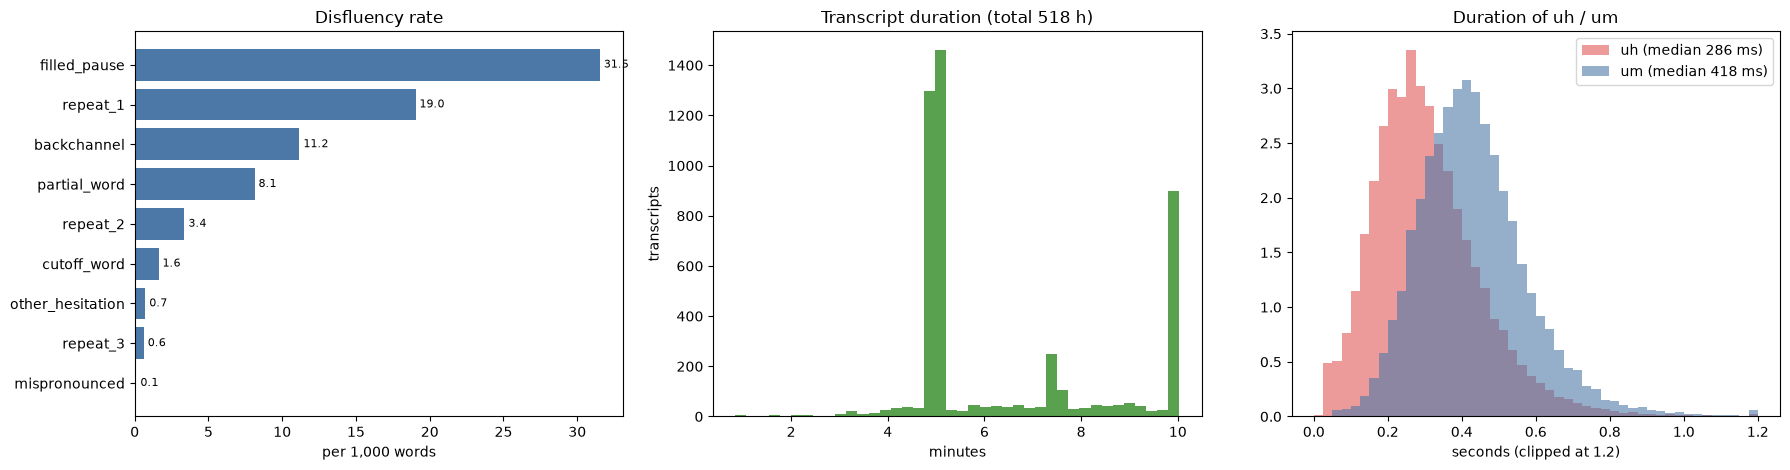

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# disfluency rates
r = stats["per 1,000 words"].sort_values()
axes[0].barh(r.index, r.values, color="#4c78a8")
axes[0].set_xlabel("per 1,000 words")
axes[0].set_title("Disfluency rate")
for y, v in enumerate(r.values):
    axes[0].text(v, y, f" {v:.1f}", va="center", fontsize=8)

# transcript durations
axes[1].hist(duration / 60, bins=40, color="#59a14f")
axes[1].set_xlabel("minutes")
axes[1].set_ylabel("transcripts")
axes[1].set_title(f"Transcript duration (total {duration.sum() / 3600:,.0f} h)")

# how long a hesitation lasts
for form, color in (("uh", "#e15759"), ("um", "#4e79a7")):
    d = words.loc[words["token"] == form, "duration"].clip(upper=1.2)
    axes[2].hist(d, bins=48, alpha=0.6, color=color, label=f"{form} (median {d.median() * 1000:.0f} ms)", density=True)
axes[2].set_xlabel("seconds (clipped at 1.2)")
axes[2].set_title("Duration of uh / um")
axes[2].legend()

plt.tight_layout()
plt.show()